# UCI CDE Python for Data Analysis Capstone  
## Complete Instructor Solution Notebook

**Case:** BrightMart Retail Analytics  
**Audience:** Instructor / solution key  
**Goal:** Demonstrate a complete end-to-end analysis using Python, pandas, and matplotlib.

This notebook intentionally includes:
- Data loading and inspection
- Data quality checks
- Cleaning and validation
- Exploratory data analysis
- Business visualizations
- Executive-level insights
- Actionable recommendations

> Instructor note: This solution is intentionally more complete than what most students are expected to submit. It can be used as an answer key, demonstration notebook, or grading reference.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

## 1. Load the Dataset

In [6]:
from google.colab import drive
drive.mount('/content/drive')
BASE_DIR = '/content/drive/MyDrive/Colab Notebooks/UCI/UCI_427.62_Python_for_Data_Analysis'
DATA_DIR = f'{BASE_DIR}/05_Datasets'
ASSIGNMENTS_DIR = f'{BASE_DIR}/04_Assignments'
OUTPUTS_DIR = f'{BASE_DIR}/04_Assignments/Outputs'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
df_raw = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/UCI/UCI_427.62_Python_for_Data_Analysis/07_Capstone_Project/UCI_CDE_Capstone_Package1B/BrightMart_Retail_Dataset.csv")
df_raw.head()

,OrderID,OrderDate,Region,Category,CustomerSegment,Sales,Discount,Profit,Quantity
0,100000,2025-06-15,West,Technology,Consumer,"4,740.37",0.15,710.59,2
1,100001,2025-08-11,South,Office Supplies,Consumer,"2,102.50",0.05,-121.23,10
2,100002,2025-10-27,East,Office Supplies,Consumer,"1,995.47",0.05,-152.93,2
3,100003,2025-10-25,West,Furniture,Corporate,"2,864.60",0.05,181.80,10
4,100004,2025-08-21,East,Furniture,Corporate,"1,820.68",0.05,445.91,10


In [8]:
print('Rows:', df_raw.shape[0])
print('Columns:', df_raw.shape[1])
df_raw.info()

Rows: 3535
Columns: 9
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3535 entries, 0 to 3534
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   OrderID          3535 non-null   int64  
 1   OrderDate        3535 non-null   object 
 2   Region           3513 non-null   object 
 3   Category         3535 non-null   object 
 4   CustomerSegment  3535 non-null   object 
 5   Sales            3535 non-null   float64
 6   Discount         3535 non-null   float64
 7   Profit           3535 non-null   float64
 8   Quantity         3535 non-null   int64  
dtypes: float64(3), int64(2), object(4)
memory usage: 248.7+ KB


## 2. Initial Data Quality Review

The dataset is designed to contain realistic problems:
- duplicate records
- inconsistent region names
- missing region values
- mixed date formats
- sales outliers
- negative profit records

In [9]:
quality_summary = pd.DataFrame({
    'missing_count': df_raw.isna().sum(),
    'missing_percent': (df_raw.isna().mean() * 100).round(2),
    'unique_values': df_raw.nunique()
})
quality_summary

,missing_count,missing_percent,unique_values
OrderID,0,0.00,3500
OrderDate,0,0.00,397
Region,22,0.62,5
Category,0,0.00,3
CustomerSegment,0,0.00,3
Sales,0,0.00,3490
Discount,0,0.00,6
Profit,0,0.00,3450
Quantity,0,0.00,12


In [10]:
duplicate_count = df_raw.duplicated().sum()
print('Duplicate rows:', duplicate_count)

print('\nRegion values:')
print(df_raw['Region'].value_counts(dropna=False))

Duplicate rows: 35

Region values:
Region
South      889
West       874
East       849
Central    836
west        65
NaN         22
Name: count, dtype: int64


## 3. Data Cleaning

Cleaning decisions:
1. Remove exact duplicate rows.
2. Standardize region capitalization.
3. Treat blank region values as missing.
4. Convert order date to datetime.
5. Add useful derived fields: month, quarter, profit margin, discount band.
6. Flag sales outliers instead of automatically deleting them.

Instructor note: In business analytics, outliers should usually be investigated before removal. A very large transaction may be valid.

In [11]:
df = df_raw.copy()

# Remove duplicates
df = df.drop_duplicates()

# Standardize text fields
df['Region'] = df['Region'].replace('', np.nan)
df['Region'] = df['Region'].astype('string').str.strip().str.title()
df['Category'] = df['Category'].astype('string').str.strip().str.title()
df['CustomerSegment'] = df['CustomerSegment'].astype('string').str.strip().str.title()

# Parse dates
df['OrderDate'] = pd.to_datetime(df['OrderDate'], errors='coerce')

# Derived fields
df['OrderMonth'] = df['OrderDate'].dt.to_period('M').astype(str)
df['Quarter'] = df['OrderDate'].dt.quarter
df['ProfitMargin'] = np.where(df['Sales'] != 0, df['Profit'] / df['Sales'], np.nan)

# Discount bands
df['DiscountBand'] = pd.cut(
    df['Discount'],
    bins=[-0.001, 0.0, 0.10, 0.20, 1.0],
    labels=['No discount', 'Low discount', 'Medium discount', 'High discount']
)

# Outlier flag using IQR
q1 = df['Sales'].quantile(0.25)
q3 = df['Sales'].quantile(0.75)
iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr
df['SalesOutlierFlag'] = df['Sales'] > upper_bound

print('Cleaned rows:', len(df))
print('Rows removed as duplicates:', len(df_raw) - len(df))
print('Sales outlier upper bound:', round(upper_bound, 2))
print('Outlier count:', df['SalesOutlierFlag'].sum())

Cleaned rows: 3500
Rows removed as duplicates: 35
Sales outlier upper bound: 7553.02
Outlier count: 26


In [12]:
clean_quality_summary = pd.DataFrame({
    'missing_count': df.isna().sum(),
    'missing_percent': (df.isna().mean() * 100).round(2),
    'unique_values': df.nunique()
})
clean_quality_summary

,missing_count,missing_percent,unique_values
OrderID,0,0.00,3500
OrderDate,32,0.91,365
Region,22,0.63,4
Category,0,0.00,3
CustomerSegment,0,0.00,3
Sales,0,0.00,3490
Discount,0,0.00,6
Profit,0,0.00,3450
Quantity,0,0.00,12
OrderMonth,0,0.00,13


## 4. Executive KPI Summary

In [13]:
kpis = {
    'Total Sales': df['Sales'].sum(),
    'Total Profit': df['Profit'].sum(),
    'Average Profit Margin': df['Profit'].sum() / df['Sales'].sum(),
    'Orders': df['OrderID'].nunique(),
    'Units Sold': df['Quantity'].sum(),
    'Negative Profit Orders': (df['Profit'] < 0).sum(),
    'Sales Outlier Orders': df['SalesOutlierFlag'].sum()
}

for key, value in kpis.items():
    if 'Sales' in key or 'Profit' in key:
        print(f'{key}: ${value:,.2f}' if key != 'Average Profit Margin' else f'{key}: {value:.2%}')
    else:
        print(f'{key}: {value:,}')

Total Sales: $9,967,002.19
Total Profit: $730,759.55
Average Profit Margin: 7.33%
Orders: 3,500
Units Sold: 23,025
Negative Profit Orders: $1,042.00
Sales Outlier Orders: $26.00


## 5. Sales and Profit by Region

In [14]:
region_summary = (
    df.groupby('Region', dropna=False)
    .agg(
        Orders=('OrderID', 'count'),
        Sales=('Sales', 'sum'),
        Profit=('Profit', 'sum'),
        AvgDiscount=('Discount', 'mean')
    )
    .assign(ProfitMargin=lambda x: x['Profit'] / x['Sales'])
    .sort_values('Profit', ascending=False)
)

region_summary

,Orders,Sales,Profit,AvgDiscount,ProfitMargin
Region,,,,,
East,842,"2,464,805.72","199,985.19",0.13,0.08
West,928,"2,710,886.88","192,626.48",0.13,0.07
South,878,"2,345,129.23","169,320.69",0.13,0.07
Central,830,"2,393,426.52","164,467.20",0.13,0.07
<NA>,22,"52,753.84","4,359.99",0.11,0.08


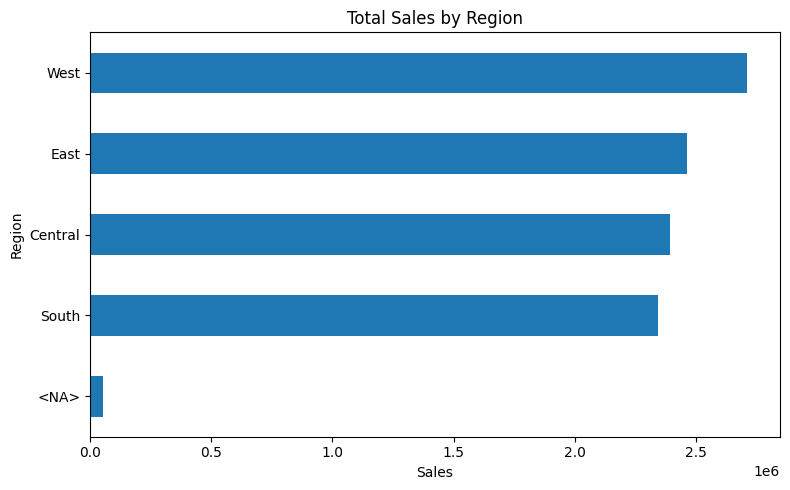

In [15]:
region_summary['Sales'].sort_values().plot(kind='barh', figsize=(8,5))
plt.title('Total Sales by Region')
plt.xlabel('Sales')
plt.ylabel('Region')
plt.tight_layout()
plt.show()

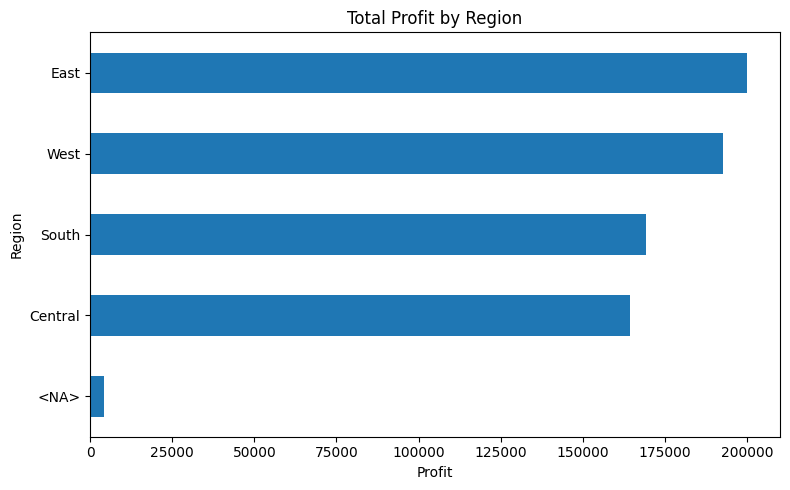

In [16]:
region_summary['Profit'].sort_values().plot(kind='barh', figsize=(8,5))
plt.title('Total Profit by Region')
plt.xlabel('Profit')
plt.ylabel('Region')
plt.tight_layout()
plt.show()

## 6. Sales and Profit by Category

In [17]:
category_summary = (
    df.groupby('Category')
    .agg(
        Orders=('OrderID', 'count'),
        Sales=('Sales', 'sum'),
        Profit=('Profit', 'sum'),
        AvgDiscount=('Discount', 'mean')
    )
    .assign(ProfitMargin=lambda x: x['Profit'] / x['Sales'])
    .sort_values('Profit', ascending=False)
)

category_summary

,Orders,Sales,Profit,AvgDiscount,ProfitMargin
Category,,,,,
Furniture,1152,"3,223,594.40","248,927.09",0.13,0.08
Office Supplies,1175,"3,512,944.53","248,847.96",0.13,0.07
Technology,1173,"3,230,463.26","232,984.50",0.13,0.07


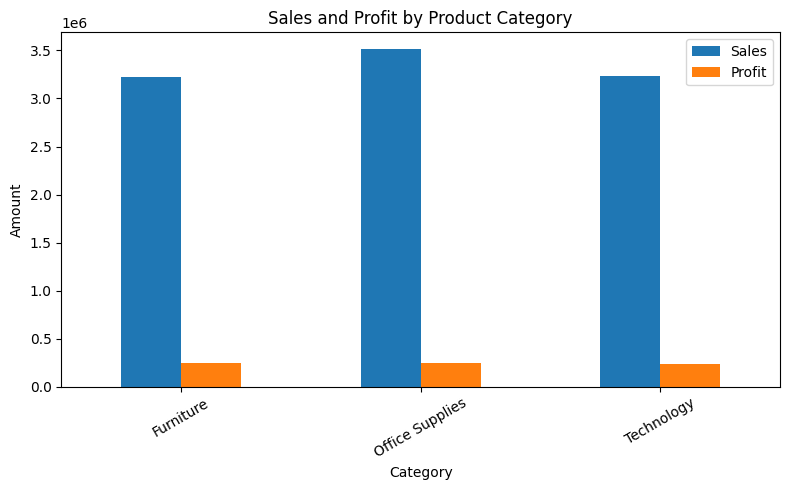

In [18]:
category_summary[['Sales','Profit']].plot(kind='bar', figsize=(8,5))
plt.title('Sales and Profit by Product Category')
plt.xlabel('Category')
plt.ylabel('Amount')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 7. Customer Segment Analysis

In [19]:
segment_summary = (
    df.groupby('CustomerSegment')
    .agg(
        Orders=('OrderID','count'),
        Sales=('Sales','sum'),
        Profit=('Profit','sum'),
        AvgOrderValue=('Sales','mean')
    )
    .assign(ProfitMargin=lambda x: x['Profit'] / x['Sales'])
    .sort_values('Profit', ascending=False)
)

segment_summary

,Orders,Sales,Profit,AvgOrderValue,ProfitMargin
CustomerSegment,,,,,
Home Office,1171,"3,316,108.71","258,867.77","2,831.86",0.08
Corporate,1150,"3,218,672.74","243,829.72","2,798.85",0.08
Consumer,1179,"3,432,220.74","228,062.06","2,911.13",0.07


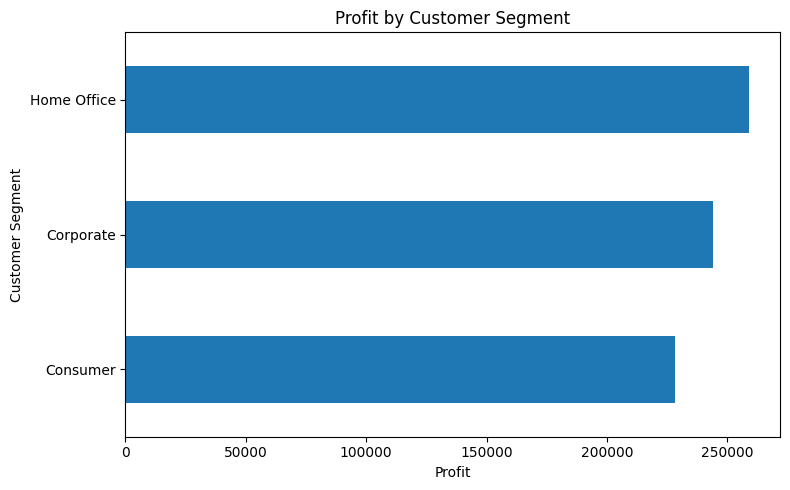

In [20]:
segment_summary['Profit'].sort_values().plot(kind='barh', figsize=(8,5))
plt.title('Profit by Customer Segment')
plt.xlabel('Profit')
plt.ylabel('Customer Segment')
plt.tight_layout()
plt.show()

## 8. Discount and Profitability Analysis

This section addresses one of the most important executive questions:  
**Are discounts reducing profitability?**

In [21]:
discount_summary = (
    df.groupby('DiscountBand', observed=True)
    .agg(
        Orders=('OrderID','count'),
        Sales=('Sales','sum'),
        Profit=('Profit','sum'),
        AvgProfitMargin=('ProfitMargin','mean'),
        NegativeProfitRate=('Profit', lambda s: (s < 0).mean())
    )
    .sort_index()
)

discount_summary

,Orders,Sales,Profit,AvgProfitMargin,NegativeProfitRate
DiscountBand,,,,,
No discount,577,"1,714,282.29","172,703.52",0.12,0.20
Low discount,1166,"3,174,847.76","306,360.75",0.11,0.24
Medium discount,1184,"3,440,479.26","216,792.16",0.07,0.33
High discount,573,"1,637,392.88","34,903.12",0.03,0.45


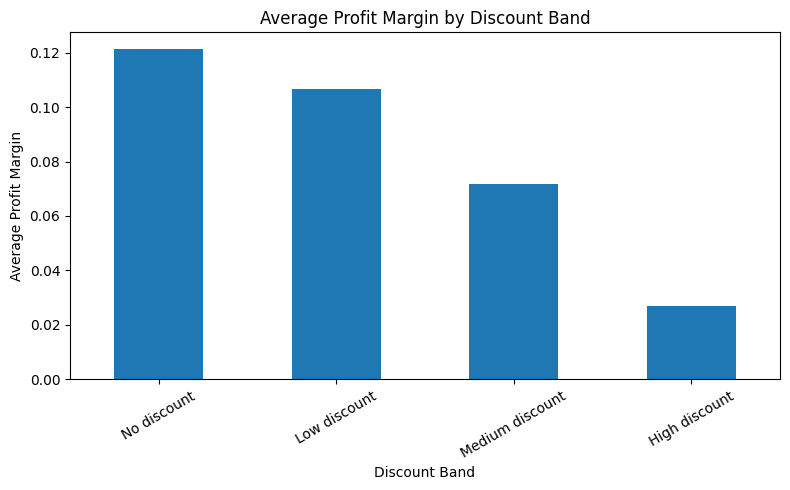

In [22]:
discount_summary['AvgProfitMargin'].plot(kind='bar', figsize=(8,5))
plt.title('Average Profit Margin by Discount Band')
plt.xlabel('Discount Band')
plt.ylabel('Average Profit Margin')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

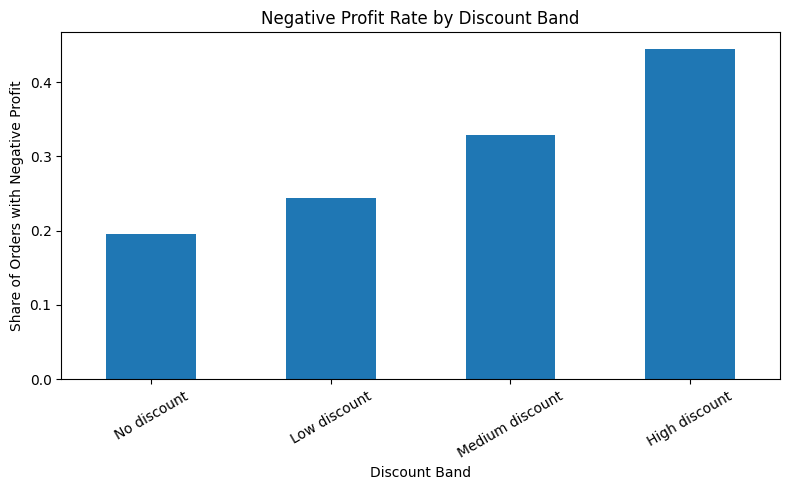

In [23]:
discount_summary['NegativeProfitRate'].plot(kind='bar', figsize=(8,5))
plt.title('Negative Profit Rate by Discount Band')
plt.xlabel('Discount Band')
plt.ylabel('Share of Orders with Negative Profit')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 9. Monthly Trend Analysis

In [24]:
monthly_summary = (
    df.groupby('OrderMonth')
    .agg(
        Sales=('Sales','sum'),
        Profit=('Profit','sum'),
        Orders=('OrderID','count')
    )
    .reset_index()
    .sort_values('OrderMonth')
)

monthly_summary.head()

,OrderMonth,Sales,Profit,Orders
0,2025-01,"824,348.38","62,736.48",286
1,2025-02,"955,704.98","64,577.00",289
2,2025-03,"725,392.03","57,491.61",287
3,2025-04,"792,499.13","67,327.17",307
4,2025-05,"688,510.95","51,655.23",275


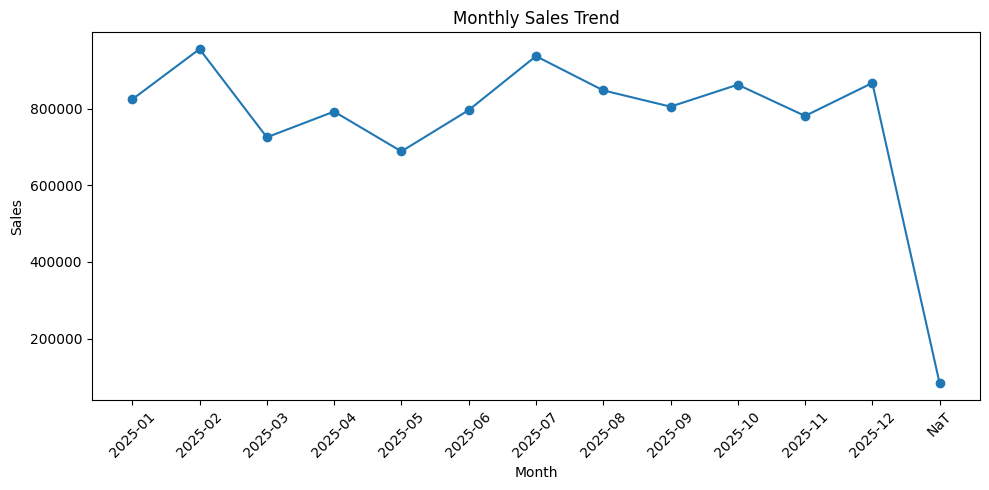

In [25]:
plt.figure(figsize=(10,5))
plt.plot(monthly_summary['OrderMonth'], monthly_summary['Sales'], marker='o')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

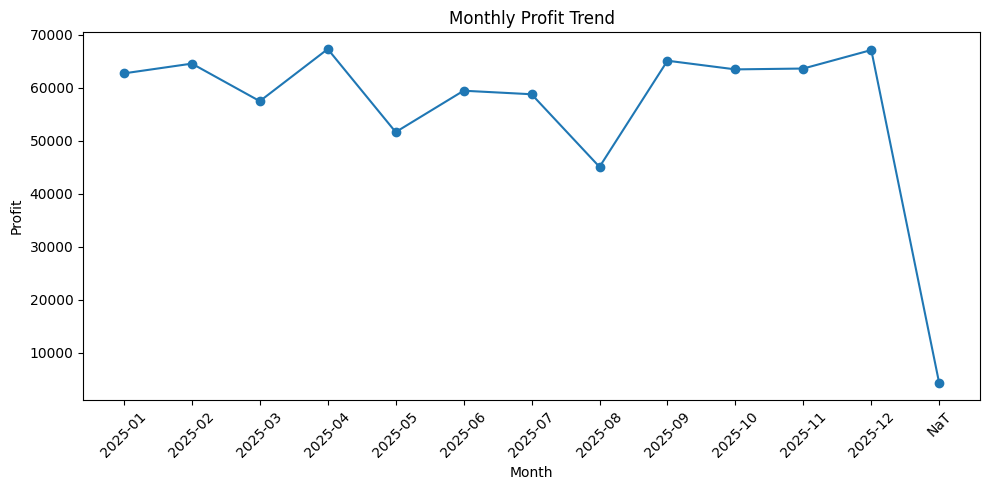

In [26]:
plt.figure(figsize=(10,5))
plt.plot(monthly_summary['OrderMonth'], monthly_summary['Profit'], marker='o')
plt.title('Monthly Profit Trend')
plt.xlabel('Month')
plt.ylabel('Profit')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 10. Outlier Review

Outliers can distort total revenue and profit. Students should identify them and explain whether they appear to be valid transactions or data-entry concerns.

In [27]:
outliers = df[df['SalesOutlierFlag']].sort_values('Sales', ascending=False)
outliers.head(10)

,OrderID,OrderDate,Region,Category,CustomerSegment,Sales,Discount,Profit,Quantity,OrderMonth,Quarter,ProfitMargin,DiscountBand,SalesOutlierFlag
2262,102262,2025-07-11,West,Office Supplies,Corporate,"87,500.40",0.00,305.33,11,2025-07,3.00,0.00,No discount,True
1177,101177,2025-12-01,East,Furniture,Home Office,"81,106.60",0.00,"1,060.80",9,2025-12,4.00,0.01,No discount,True
1845,101845,2025-02-17,Central,Office Supplies,Consumer,"78,323.60",0.20,-15.11,7,2025-02,1.00,-0.00,Medium discount,True
2865,102865,2025-11-25,West,Technology,Home Office,"77,845.60",0.05,"1,013.95",12,2025-11,4.00,0.01,Low discount,True
2956,102956,2025-08-02,East,Office Supplies,Consumer,"75,244.40",0.20,-79.21,4,2025-08,3.00,-0.00,Medium discount,True
3430,103430,2025-02-05,Central,Office Supplies,Consumer,"72,340.20",0.10,147.90,4,2025-02,1.00,0.00,Low discount,True
695,100695,2025-08-11,South,Furniture,Consumer,"66,660.80",0.20,940.70,12,2025-08,3.00,0.01,Medium discount,True
210,100210,2025-01-31,West,Office Supplies,Consumer,"63,157.80",0.20,-318.38,5,2025-01,1.00,-0.01,Medium discount,True
1535,101535,2025-02-08,Central,Technology,Home Office,"62,316.20",0.00,-233.75,2,2025-02,1.00,-0.00,No discount,True
164,100164,2025-06-08,East,Office Supplies,Consumer,"60,847.00",0.30,-30.23,9,2025-06,2.00,-0.00,High discount,True


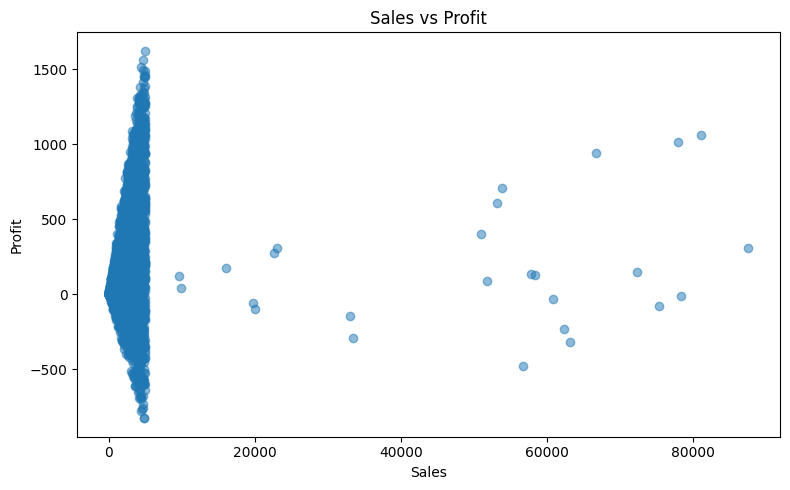

In [28]:
plt.figure(figsize=(8,5))
plt.scatter(df['Sales'], df['Profit'], alpha=0.5)
plt.title('Sales vs Profit')
plt.xlabel('Sales')
plt.ylabel('Profit')
plt.tight_layout()
plt.show()

## 11. Business Findings

Based on the analysis, a strong student submission should identify findings similar to the following.

### Finding 1: Revenue and profit are not the same story
Some categories or regions may generate high sales but weaker margins. Management should not evaluate performance using sales volume alone.

### Finding 2: Discounting appears to pressure profit margin
Higher discount bands generally show lower average profit margin and higher negative-profit risk. Discounts should be reviewed by category and customer segment.

### Finding 3: Customer segment strategy matters
The most profitable customer segment should receive targeted retention efforts, while lower-margin segments may require pricing or promotion adjustments.

### Finding 4: Data quality affects management confidence
Duplicate records, inconsistent region names, missing values, mixed dates, and outliers must be addressed before using the data for executive decisions.

### Finding 5: Trend analysis can support quarterly planning
Monthly sales and profit trends help identify seasonal patterns and potential periods for promotional activity.

## 12. Executive Recommendations

### Recommendation 1: Control high-discount activity
Require manager approval for high-discount transactions, especially when expected margins are low.

### Recommendation 2: Shift focus from revenue growth to profitable growth
Add profit margin and negative-profit rate to regular performance dashboards.

### Recommendation 3: Review category-level pricing
Identify categories with strong sales but weak margins and evaluate pricing, supplier costs, or discount rules.

### Recommendation 4: Improve customer segmentation strategy
Prioritize retention campaigns for higher-margin segments and redesign promotions for lower-margin segments.

### Recommendation 5: Strengthen data governance
Standardize region names, validate order dates, review large sales outliers, and remove duplicate transactions before reporting.

### Recommendation 6: Build a recurring Python reporting workflow
Automate monthly cleaning, KPI calculation, and visualization to support executive decision-making.

## 13. Suggested Grading Guidance for Instructor

A complete student notebook should include:

- Correct import and inspection of data
- Clear data cleaning decisions
- At least 6 meaningful visualizations
- Region, category, segment, discount, and trend analysis
- Identification of data quality issues
- Business recommendations supported by evidence
- Clean code with readable comments
- Executive-friendly interpretation

Instructor note: Students should not only show code output. They should explain what the output means for the business.

In [29]:
# Optional: export cleaned dataset for student/instructor review
df.to_csv('BrightMart_Retail_Dataset_Cleaned_Instructor_Solution.csv', index=False)
print('Cleaned dataset exported.')

Cleaned dataset exported.
